# More Power Spectra Examples

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad_vec
from field_kit import FourierAnalysis, GaussianRandomField, PowerLawBetaModel

In [2]:
# Parameters for the Gaussian random fields
l_min = 1.0  # minimum or "dissipation" scale
l_max = 200.0  # maximum or "injection" scale
alpha = -11.0 / 3.0
f_rms = 10.0  # normalization of the field

In [3]:
# Make two power spectra with different l_min values
power_spec = PowerLawBetaModel(l_min, l_max, alpha)

In [4]:
# Renormalize the power spectra to have the desired RMS value
power_spec.renormalize(f_rms)

In [5]:
# Parameters for the box and grid
le = np.array([0.0, 0.0, 0.0])
re = np.array([750.0, 750.0, 750.0])
ddims = [256] * 3
width = re - le

In [6]:
# This is a class I wrote to simplify stuff
fa = FourierAnalysis(width, ddims)

In [7]:
# This makes a Gaussian random field with the specified power spectrum
g = GaussianRandomField(le, re, ddims, power_spec, seed=20)
B = g.generate_vector_field_realization(divergence_free=True)

In [8]:
kmin = 0.0
kmax = 100.0  # a really big number to approximate infinity

def P1_int(k_perp, eta):
    k = np.sqrt(eta ** 2 + k_perp ** 2)
    return 2.0*np.pi*power_spec(k)*k_perp/(2.0*np.pi)/3.0

eta = fa.kx[:128, 0, 0]

P_1D = quad_vec(P1_int, kmin, kmax, args=(eta,), points=(0.1, 1.0, 10.0, 30.0))[0]

In [9]:
P_3D = fa.make_powerspec(B)
P_1Ds = fa.integrate_kspace(P_3D, axis=(1, 2)).average_symmetric_k()

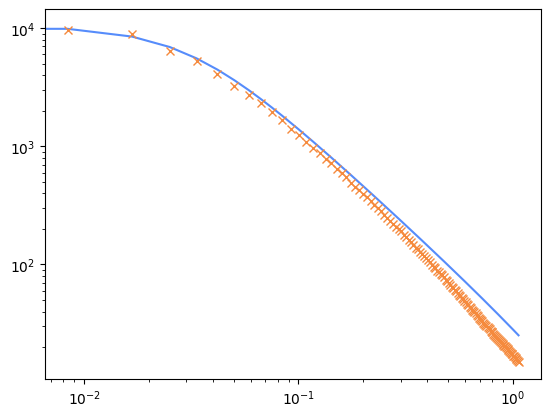

In [10]:
plt.figure()
plt.loglog(eta, P_1D, label="1D Power Spectrum")
plt.loglog(eta, P_1Ds.sum(axis=0), 'x')